Train with just koopman matrix and then adding sequence model later


In [1]:
#Make sure you are in directory: Mori-Zwanzig-Autoencoder/
import os
os.chdir("../../")
print(os.getcwd())

/rds/general/user/pg221/home/PhD_projects/MZ-AE


In [2]:
import torch, pickle, os
from torch.utils.data import Dataset, DataLoader
from src.PreProc_Data.DataProc import StackedSequenceDataset
import numpy as np
from src.Eval_MZA import Eval_MZA
import matplotlib.pyplot as plt
import pandas as pd
import csv

# Load Models

In [3]:
torch.cuda.empty_cache()
exp_dir = "Trained_Models/2DCyl/Case1"
models = []

exp_name_list = [
                 "Koopman_AE",\
                 "MZi-AE_LRNN",\  
                 ]
# exp_name_list = os.listdir(exp_dir)
exp_name_list = [exp_name for exp_name in exp_name_list if "ignore" not in exp_name]
for exp_name in exp_name_list:
    if exp_name != "results" and exp_name != ".DS_Store":
        print(exp_name)
        models.append(Eval_MZA(exp_dir, exp_name))

Koopman_AE
########## Imp Info ##########
System:  ExpData
########## Imp Info ##########
System:  2DCyl
Training without Seqmodel
MZ-AE_LRNN_3
########## Imp Info ##########
System:  ExpData
########## Imp Info ##########
System:  2DCyl


## Load Data

In [4]:
model_num = 0
models[model_num].load_and_preproc_data()
models[model_num].create_dataset(mode = "Both")
dataset = models[model_num].test_dataset
num_trajs = models[model_num].test_num_trajs


#Test Data
Phi_test = models[0].test_data
Phi_test = torch.from_numpy(Phi_test).to(torch.float32).to(models[0].device)
U = Phi_test[...,:int(Phi_test.shape[-1]/2)].detach().cpu().numpy()
V = Phi_test[...,int(Phi_test.shape[-1]/2):].detach().cpu().numpy()

State Dims:  7938
Train_Shape:  (1, 1046, 7938)
Time:  13.390980958938599
Test_Shape:  (1, 1046, 7938)
Time:  7.190290212631226


## Load Weights

In [10]:
for i in range(len(models)):
#     if i==1:
#         models[i].load_weights(other = True)
#     else:
    models[i].load_weights(other = True)

# Training GFDc using markov operator of Koopman-AE

In [11]:
from torch.utils.data import TensorDataset, DataLoader
from src.Train_Methods import Train_GFDc

train_gfdc = Train_GFDc(models[0])

#creating data
data = torch.tensor(models[0].train_data[0])
num_memory_kernels = 90
xn_data, sequences, dec_xn_data = train_gfdc.get_observables_data(data, num_memory_kernels = num_memory_kernels)

#Obtaining memory kernels
omega = train_gfdc.gfdc_memory_reg(xn_data = xn_data.detach().cpu().numpy(), num_memory_kernels = num_memory_kernels) 

#using model for prediction
timesteps = 1046
initial_condition = torch.tensor(models[0].test_data[0,100-(num_memory_kernels+1):100]).to(torch.float32)[None]
pred_data, Phi_ms_hat_gfdc = train_gfdc.predict(initial_condition = initial_condition, timesteps = timesteps, num_kernels = num_memory_kernels, omega = omega)

#Predicted Velocity
U_ms_hat_gfdc = Phi_ms_hat_gfdc[...,:int(Phi_ms_hat_gfdc.shape[-1]/2)].detach().cpu().numpy()
V_ms_hat_gfdc = Phi_ms_hat_gfdc[...,int(Phi_ms_hat_gfdc.shape[-1]/2):].detach().cpu().numpy()
print(U_ms_hat_gfdc.shape, V_ms_hat_gfdc.shape)

/rds/general/user/pg221/home/PhD_projects/MZ-AE/src/Train_Methods/Train_GFDc.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  seq = torch.tensor(data[i:i+sequence_length], dtype = torch.float32)
/rds/general/user/pg221/home/PhD_projects/MZ-AE/src/Train_Methods/Train_GFDc.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(data[i+sequence_length], dtype = torch.float32)
/rds/general/user/pg221/home/PhD_projects/MZ-AE/src/Train_Methods/Train_GFDc.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.te

(1, 1137, 3969) (1, 1137, 3969)


## Prediction

In [14]:
#multistep prediction
timesteps = 4000     
initial_step = 100
# initial_conditions = Phi_test[:,initial_step,:]
initial_conditions = Phi_test[:,initial_step-(num_memory_kernels+1):initial_step]


#Need single step as initial_condition for Koopman-AE and MZ-AE LRNN
initial_condition = initial_conditions[:,-1]
#Need an array of memory for GFDc
initial_condition_gfdc = initial_conditions

#using GFDc for prediction
pred_data, Phi_ms_hat_gfdc = train_gfdc.predict(initial_condition = initial_condition_gfdc, timesteps = timesteps, num_kernels = num_memory_kernels, omega = omega)

#Predicted Velocity
U_ms_hat_gfdc = Phi_ms_hat_gfdc[...,:int(Phi_ms_hat_gfdc.shape[-1]/2)].detach().cpu().numpy()
V_ms_hat_gfdc = Phi_ms_hat_gfdc[...,int(Phi_ms_hat_gfdc.shape[-1]/2):].detach().cpu().numpy()
print(U_ms_hat_gfdc.shape, V_ms_hat_gfdc.shape)

#Using Koopman-AE and LRNN for prediction
x_ms_hat, xkoop_ms_hat, xseq_ms_hat = [], [], []
Phi_ms_hat = torch.zeros((len(models),1,timesteps+1,models[0].statedim)).to(models[0].device)
Phi_ms_koop = torch.zeros((len(models),1,timesteps,models[0].statedim)).to(models[0].device)

for i in range(len(models)):
    x_hat_temp, Phi_ms_hat[i], xkoop_hat_temp, xseq_hat_temp = models[i].predict_multistep(initial_condition, timesteps)
    x_ms_hat.append(x_hat_temp)
    xkoop_ms_hat.append(xkoop_hat_temp)
    xseq_ms_hat.append(xseq_hat_temp)

#Predicted Velocity
U_ms_hat = Phi_ms_hat[...,:int(Phi_ms_hat.shape[-1]/2)].detach().cpu().numpy()
V_ms_hat = Phi_ms_hat[...,int(Phi_ms_hat.shape[-1]/2):].detach().cpu().numpy()

U_ms_hat.shape, V_ms_hat.shape, U.shape, V.shape

(1, 4091, 3969) (1, 4091, 3969)


((2, 1, 4001, 3969), (2, 1, 4001, 3969), (1, 1046, 3969), (1, 1046, 3969))

# Short Term prediction

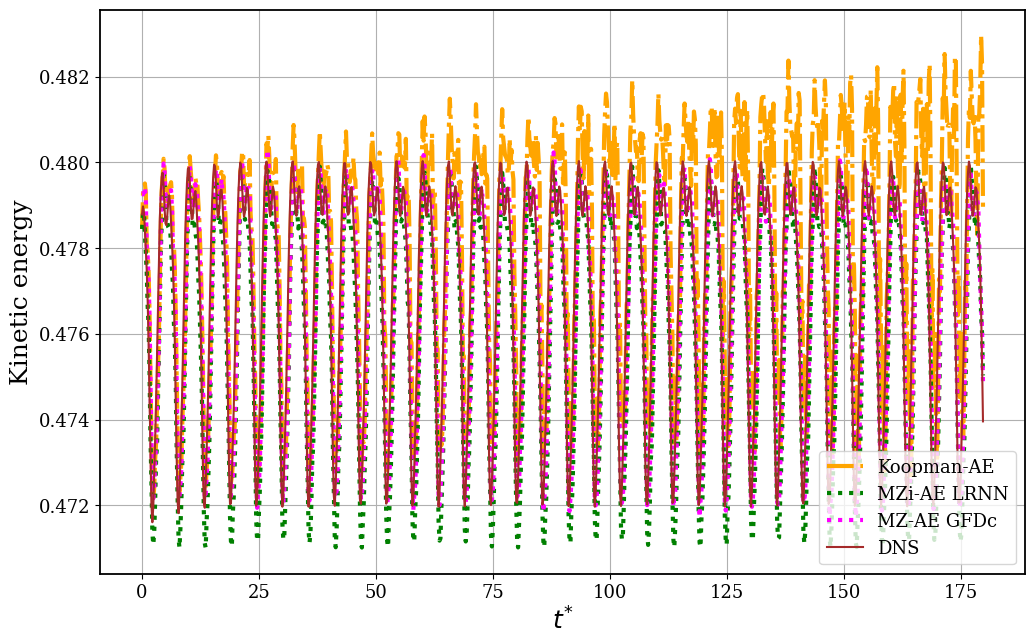

In [21]:
#calculating kinetic energy for multistep prediction 
def energy(u,v):
    k = 0.5*(np.mean(u**2,axis=-1) + np.mean(v**2,axis=-1))
    return k

k = energy(U, V)
k_ms_pred = energy(U_ms_hat, V_ms_hat)
k_ms_pred_gfdc = energy(U_ms_hat_gfdc, V_ms_hat_gfdc)

initial_step = 100 
plt.figure(figsize=(10, 6))

plt.plot(np.arange(k_ms_pred[0,0,:900].shape[-1])*0.2,k_ms_pred[0,0,:900],  "-.", label = f"Koopman-AE", lw=3, color = "orange")
plt.plot(np.arange(k_ms_pred[1,0,:900].shape[-1])*0.2,k_ms_pred[1,0,:900],  ":", label = "MZi-AE LRNN", lw=3, color= "green")
plt.plot(np.arange(k_ms_pred_gfdc[0,num_memory_kernels:num_memory_kernels+900].shape[-1])*0.2,k_ms_pred_gfdc[0,num_memory_kernels:num_memory_kernels+900], ":", label = f"MZ-AE GFDc", lw=3, color = "magenta")

plt.plot(np.arange(k[0,initial_step:initial_step+900].shape[-1])*0.2,k[0,initial_step:initial_step+900], label = "DNS",color = "brown")


plt.rc('font',family = 'serif',  size=13)
plt.subplots_adjust(right=1.05, top=1.05) 
plt.legend(loc='lower right')
plt.grid("on")

# Set labels and title
plt.xlabel(r'$t^{*}$', fontsize = 18)
plt.ylabel('Kinetic energy', fontsize = 18)
# plt.xlim(0,210)

# Darken the axes by modifying the spines
ax = plt.gca()  # Get the current axes
ax.set_aspect("auto")
for spine in ax.spines.values():
    spine.set_color('black')     # Darken the color to black
    spine.set_linewidth(1.3)    # Increase the line width for emphasis

# Long term prediction

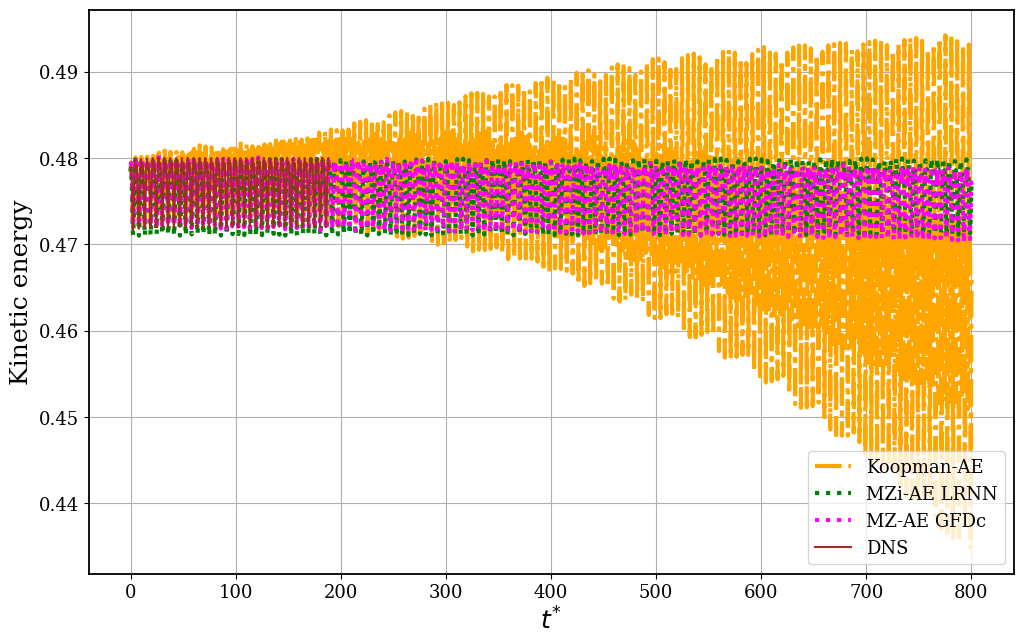

In [22]:
#calculating kinetic energy for multistep prediction 
def energy(u,v):
    k = 0.5*(np.mean(u**2,axis=-1) + np.mean(v**2,axis=-1))
    return k

k = energy(U, V)
k_ms_pred = energy(U_ms_hat, V_ms_hat)
k_ms_pred_gfdc = energy(U_ms_hat_gfdc, V_ms_hat_gfdc)

initial_step = 100 
plt.figure(figsize=(10, 6))

plt.plot(np.arange(k_ms_pred.shape[-1])*0.2,k_ms_pred[0,0,:],  "-.", label = f"Koopman-AE", lw=3, color = "orange")
plt.plot(np.arange(k_ms_pred.shape[-1])*0.2,k_ms_pred[1,0,:],  ":", label = "MZi-AE LRNN", lw=3, color= "green")
plt.plot(np.arange(k_ms_pred_gfdc[0,num_memory_kernels:].shape[-1])*0.2,k_ms_pred_gfdc[0,num_memory_kernels:], ":", label = f"MZ-AE GFDc", lw=3, color = "magenta")

plt.plot(np.arange(k[0,initial_step:].shape[-1])*0.2,k[0,initial_step:], label = "DNS",color = "brown")


plt.rc('font',family = 'serif',  size=13)
plt.subplots_adjust(right=1.05, top=1.05) 
plt.legend(loc='lower right')
plt.grid("on")

# Set labels and title
plt.xlabel(r'$t^{*}$', fontsize = 18)
plt.ylabel('Kinetic energy', fontsize = 18)
# plt.xlim(0,210)

# Darken the axes by modifying the spines
ax = plt.gca()  # Get the current axes
ax.set_aspect("auto")
for spine in ax.spines.values():
    spine.set_color('black')     # Darken the color to black
    spine.set_linewidth(1.3)    # Increase the line width for emphasis